In [1]:
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# !pip install pandas scikit-learn matplotlib seaborn tqdm torchmetrics timm

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from tkinter import filedialog, Tk

In [3]:
IMG_DIR = r"d:\6 semester\coursework\peat_wet\images"
TRAIN_CSV = r"d:\6 semester\coursework\peat_wet\train_labels.csv"
VAL_CSV = r"d:\6 semester\coursework\peat_wet\val_labels.csv"
MODEL_PATH = "best_peat_model_full.pth" # Файл для сохранения/загрузки
CLASS_NAMES = [f"Class {i}" for i in range(8)]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class PeatMoistureDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.labels = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        row = self.labels.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, int(row['class'])

Аугментация

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = PeatMoistureDataset(TRAIN_CSV, IMG_DIR, train_transform)
val_dataset = PeatMoistureDataset(VAL_CSV, IMG_DIR, val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, pin_memory=True)

Модель и функция потерь

In [5]:
def get_model(num_classes=8):
    model = models.efficientnet_b0(pretrained=True)
    num_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(num_features, num_classes)
    )
    return model.to(device)

model = get_model()

y_train = pd.read_csv(TRAIN_CSV)['class'].values
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

c:\pythooon\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\pythooon\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
start_epoch = 0
best_acc = 0.0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

if os.path.exists(MODEL_PATH):
    print(f"Найдена сохраненная модель. Загрузка...")
    checkpoint = torch.load(MODEL_PATH)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_acc = checkpoint['best_acc']
    history = checkpoint.get('history', history)
    print(f"Продолжаем с эпохи {start_epoch}. Лучшая точность: {best_acc:.4f}")

обучение

In [7]:
def train_and_validate(epochs_to_add=20):
    global best_acc
    for epoch in range(start_epoch, start_epoch + epochs_to_add):
        model.train()
        t_loss, t_corr, t_total = 0, 0, 0
        for imgs, lbls in tqdm(train_loader, desc=f"Epoch {epoch+1} Train"):
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
            _, pred = out.max(1)
            t_total += lbls.size(0)
            t_corr += pred.eq(lbls).sum().item()
        
        model.eval()
        v_loss, v_corr, v_total = 0, 0, 0
        with torch.no_grad():
            for imgs, lbls in tqdm(val_loader, desc="Validating"):
                imgs, lbls = imgs.to(device), lbls.to(device)
                out = model(imgs)
                loss = criterion(out, lbls)
                v_loss += loss.item()
                _, pred = out.max(1)
                v_total += lbls.size(0)
                v_corr += pred.eq(lbls).sum().item()

        train_acc, val_acc = t_corr/t_total, v_corr/v_total
        history['train_loss'].append(t_loss/len(train_loader))
        history['val_loss'].append(v_loss/len(val_loader))
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        scheduler.step(val_acc)
        print(f"Epoch {epoch+1}: Train Acc {train_acc:.4f} | Val Acc {val_acc:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

        if val_acc > best_acc:
            best_acc = val_acc
            save_dict = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_acc': best_acc,
                'history': history
            }
            torch.save(save_dict, MODEL_PATH)
            print(f"--- Модель сохранена! ---")

предсказание

Validating: 100%|██████████| 15/15 [00:23<00:00,  1.57s/it]


Epoch 1: Train Acc 0.2694 | Val Acc 0.4615 | LR: 0.000100
--- Модель сохранена! ---


Validating: 100%|██████████| 15/15 [00:22<00:00,  1.51s/it]


Epoch 2: Train Acc 0.3922 | Val Acc 0.4957 | LR: 0.000100
--- Модель сохранена! ---


Validating: 100%|██████████| 15/15 [00:21<00:00,  1.42s/it]


...

Epoch 13: Train Acc 0.7500 | Val Acc 0.7436 | LR: 0.000100
--- Модель сохранена! ---


Validating: 100%|██████████| 15/15 [00:38<00:00,  2.60s/it]


Epoch 14: Train Acc 0.7586 | Val Acc 0.7436 | LR: 0.000100


Validating: 100%|██████████| 15/15 [00:36<00:00,  2.41s/it]


Epoch 15: Train Acc 0.7112 | Val Acc 0.7521 | LR: 0.000100
--- Модель сохранена! ---


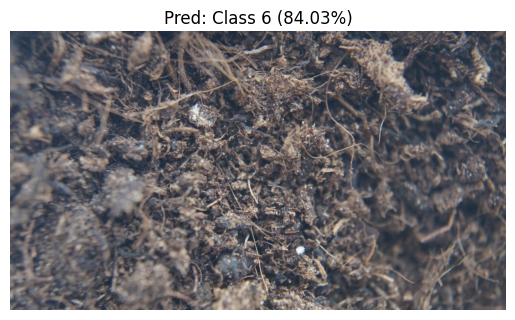

In [8]:
def predict_selected_image():
    root = Tk()
    root.withdraw()
    file_path = filedialog.askopenfilename()
    root.destroy()
    
    if not file_path: return

    model.eval()
    image = Image.open(file_path).convert('RGB')
    input_tensor = val_transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        conf, pred = torch.max(probs, 1)
    
    plt.imshow(image)
    plt.title(f"Pred: {CLASS_NAMES[pred.item()]} ({conf.item():.2%})")
    plt.axis('off')
    plt.show()

train_and_validate(epochs_to_add=15)

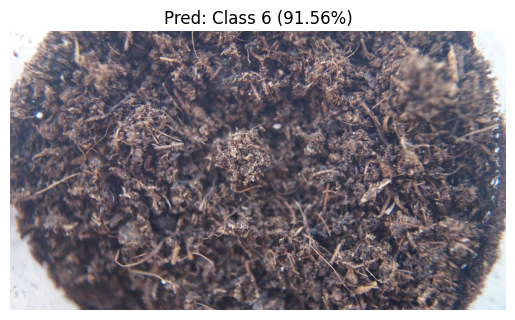

In [12]:
predict_selected_image()

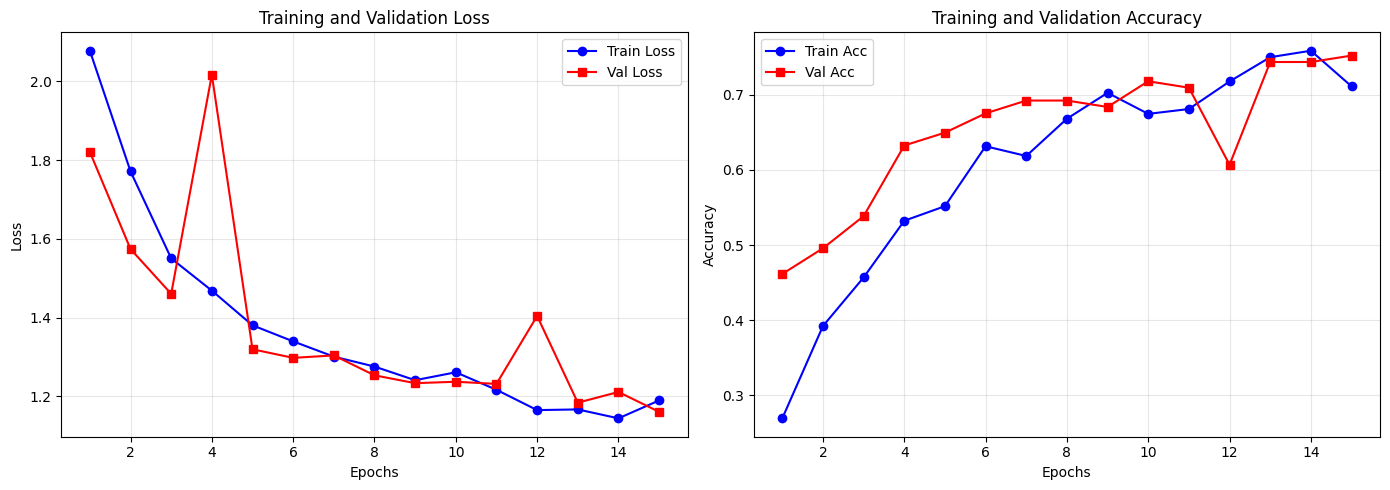

In [13]:
def plot_history(model_path):
    checkpoint = torch.load(model_path)
    if 'history' not in checkpoint:
        print("В файле нет истории обучения.")
        return
    
    hist = checkpoint['history']
    epochs = range(1, len(hist['train_loss']) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist['train_loss'], 'b-o', label='Train Loss')
    plt.plot(epochs, hist['val_loss'], 'r-s', label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist['train_acc'], 'b-o', label='Train Acc')
    plt.plot(epochs, hist['val_acc'], 'r-s', label='Val Acc')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history("best_peat_model_full.pth")

Evaluating: 100%|██████████| 15/15 [00:21<00:00,  1.45s/it]



Детальный отчет по классам:
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00         2
     Class 1       0.73      0.80      0.76        10
     Class 2       0.79      0.86      0.83        22
     Class 3       0.82      0.67      0.73        27
     Class 4       0.74      0.70      0.72        20
     Class 5       0.69      0.75      0.72        12
     Class 6       0.64      0.75      0.69        12
     Class 7       0.75      0.75      0.75        12

    accuracy                           0.75       117
   macro avg       0.77      0.79      0.78       117
weighted avg       0.76      0.75      0.75       117



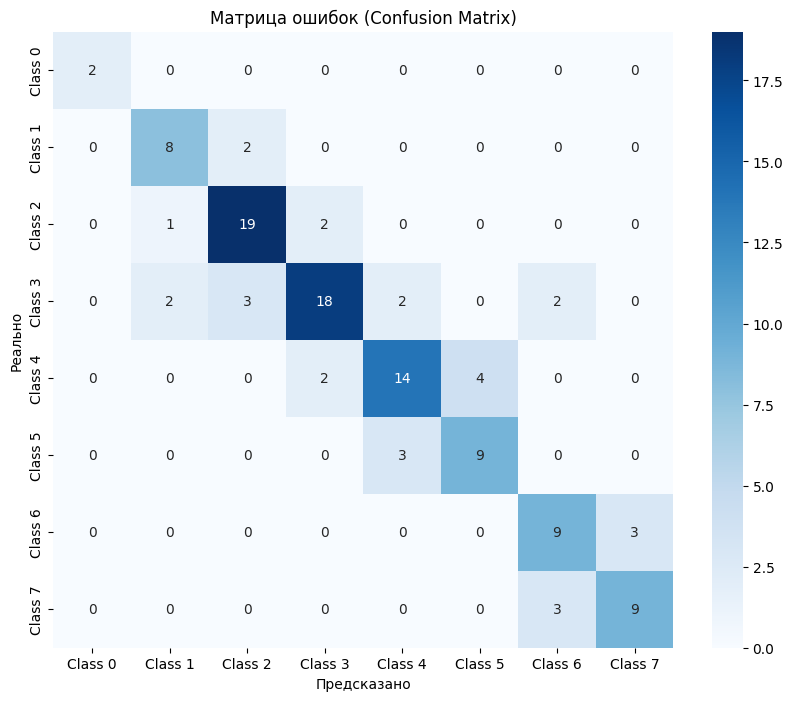

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def show_detailed_metrics(model, loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Evaluating"):
            imgs = imgs.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.numpy())

    print("\nДетальный отчет по классам:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Предсказано')
    plt.ylabel('Реально')
    plt.title('Матрица ошибок (Confusion Matrix)')
    plt.show()

show_detailed_metrics(model, val_loader, device, CLASS_NAMES)

In [15]:
train_and_validate(epochs_to_add=5)

Validating: 100%|██████████| 15/15 [00:21<00:00,  1.44s/it]


Epoch 1: Train Acc 0.7737 | Val Acc 0.7009 | LR: 0.000100


Validating: 100%|██████████| 15/15 [00:21<00:00,  1.46s/it]


Epoch 2: Train Acc 0.7414 | Val Acc 0.7265 | LR: 0.000100


Validating: 100%|██████████| 15/15 [00:21<00:00,  1.44s/it]


Epoch 3: Train Acc 0.7716 | Val Acc 0.7179 | LR: 0.000100


Validating: 100%|██████████| 15/15 [00:21<00:00,  1.42s/it]


Epoch 4: Train Acc 0.8147 | Val Acc 0.7949 | LR: 0.000100
--- Модель сохранена! ---


Validating: 100%|██████████| 15/15 [00:21<00:00,  1.41s/it]

Epoch 5: Train Acc 0.8103 | Val Acc 0.7521 | LR: 0.000100


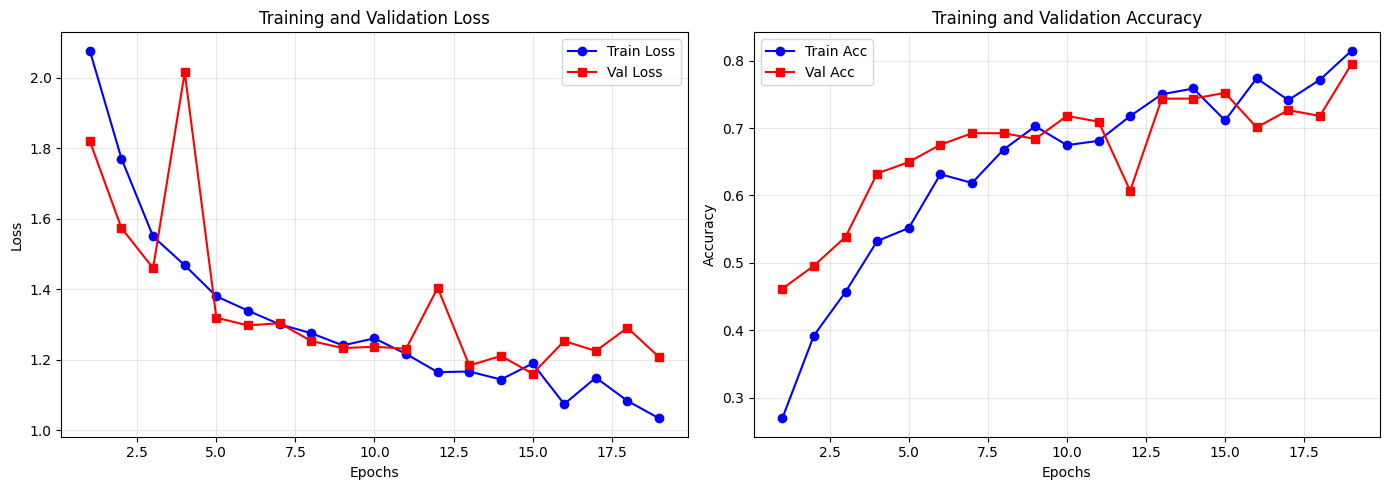

In [16]:
def plot_history(model_path):
    checkpoint = torch.load(model_path)
    if 'history' not in checkpoint:
        print("В файле нет истории обучения.")
        return
    
    hist = checkpoint['history']
    epochs = range(1, len(hist['train_loss']) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist['train_loss'], 'b-o', label='Train Loss')
    plt.plot(epochs, hist['val_loss'], 'r-s', label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist['train_acc'], 'b-o', label='Train Acc')
    plt.plot(epochs, hist['val_acc'], 'r-s', label='Val Acc')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history("best_peat_model_full.pth")

Evaluating: 100%|██████████| 15/15 [00:22<00:00,  1.48s/it]


Детальный отчет по классам:
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00         2
     Class 1       0.62      0.80      0.70        10
     Class 2       0.80      0.91      0.85        22
     Class 3       0.86      0.67      0.75        27
     Class 4       0.63      0.85      0.72        20
     Class 5       0.80      0.33      0.47        12
     Class 6       0.77      0.83      0.80        12
     Class 7       0.82      0.75      0.78        12

    accuracy                           0.75       117
   macro avg       0.79      0.77      0.76       117
weighted avg       0.77      0.75      0.74       117



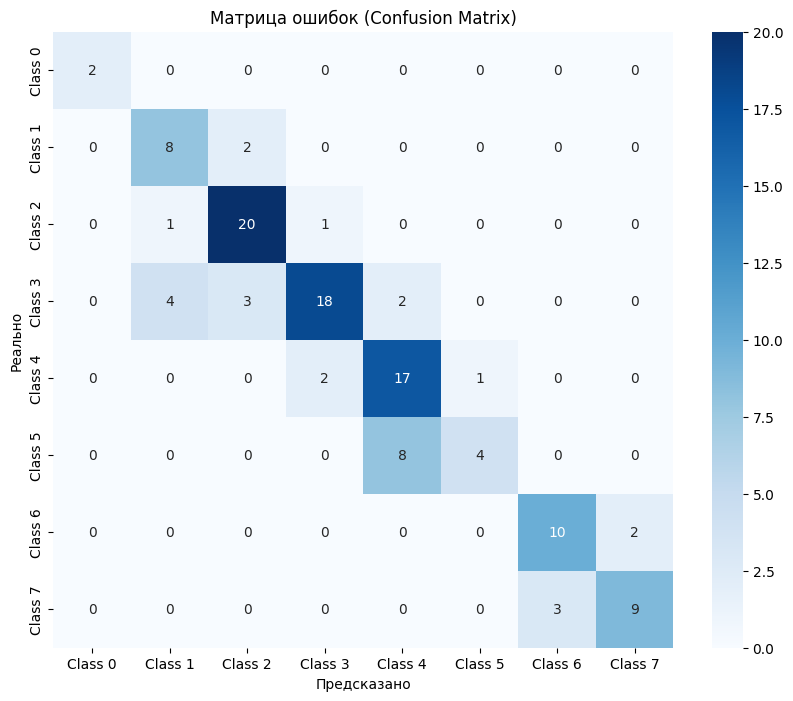

In [17]:
def show_detailed_metrics(model, loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Evaluating"):
            imgs = imgs.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.numpy())

    print("\nДетальный отчет по классам:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Предсказано')
    plt.ylabel('Реально')
    plt.title('Матрица ошибок (Confusion Matrix)')
    plt.show()

show_detailed_metrics(model, val_loader, device, CLASS_NAMES)